<a href="https://colab.research.google.com/github/wicksito/Monter-Carlo/blob/main/C%C3%B3pia_de_Atividade_3_Simula%C3%A7%C3%A3o_de_Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simulação de Monte Carlo - Caso TechToy**
1. **Introdução e Contexto**

A empresa TechToy está prestes a lançar um novo drone no mercado. A diretoria está em dúvida entre duas estratégias de lançamento e contratou você, analista de dados, para realizar uma Simulação de Monte Carlo.

O objetivo é entender não apenas o lucro esperado, mas o risco de prejuízo de cada decisão.

As Estratégias:
Estratégia A (Conservadora): Foca em um público de nicho, com preço mais alto e vendas mais previsíveis.

Estratégia B (Agressiva): Foca em escala, com preço menor, mas com custos de produção e volume de vendas muito mais incertos.

**2. Base de Dados e Parâmetros**

Execute a célula abaixo para carregar as bibliotecas necessárias e os parâmetros oficiais fornecidos pelo departamento financeiro.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações da Simulação
N_SIMULACOES = 10000

# --- PARÂMETROS ESTRATÉGIA A ---
vendas_media_a = 500
vendas_desvio_a = 50
custo_min_a = 600
custo_max_a = 700
preco_venda_a = 1200
investimento_fixo_a = 50000

# --- PARÂMETROS ESTRATÉGIA B ---
vendas_media_b = 800
vendas_desvio_b = 250
custo_min_b = 400
custo_max_b = 800
preco_venda_b = 1000
investimento_fixo_b = 150000

print("Parâmetros carregados com sucesso!")

Parâmetros carregados com sucesso!


3. Desafio

**1: Modelagem do Lucro**

Crie uma função ou um script que utilize os parâmetros acima para gerar 10.000 resultados possíveis de lucro para cada estratégia.Dicas:Para as Vendas, use uma distribuição Normal: np.random.normal(media, desvio, N_SIMULACOES).Para o Custo Unitário, use uma distribuição Uniforme: np.random.uniform(min, max, N_SIMULACOES).

A fórmula do lucro é:

$Lucro = (Vendas \times Preço) - (Vendas \times Custo\_Unitário) - Investimento\_Fixo$

In [6]:
# Vendas A e B distribuição normal
vendas_a = np.random.normal(vendas_media_a, vendas_desvio_a, N_SIMULACOES)
vendas_b = np.random.normal(vendas_media_b, vendas_desvio_b, N_SIMULACOES)

# Custo unitário de A e B pela distribuição uniforme
custo_unitario_a = np.random.uniform(custo_min_a, custo_max_a, N_SIMULACOES)
custo_unitario_b = np.random.uniform(custo_min_b, custo_max_b, N_SIMULACOES)

# Cálculo de lucro de A e B
lucro_a = (vendas_a * preco_venda_a) - (vendas_a * custo_unitario_a)
lucro_b = (vendas_b * preco_venda_b) - (vendas_b * custo_unitario_b)

# Lucro médio de A e B
media_lucro_a = np.mean(lucro_a)
media_lucro_b = np.mean(lucro_b)

# Percentis de A e B

# Cenário pessimista
p5_a = np.percentile(lucro_a, 5)
p5_b = np.percentile(lucro_b, 5)

# Cenário positivo
p95_a = np.percentile(lucro_a, 95)
p95_b = np.percentile(lucro_b, 95)

**2: Visualização dos Resultados**

Gere um histograma comparando as duas estratégias. O gráfico deve ajudar a diretoria a visualizar onde o lucro se concentra e onde estão os riscos de perda (valores abaixo de zero).

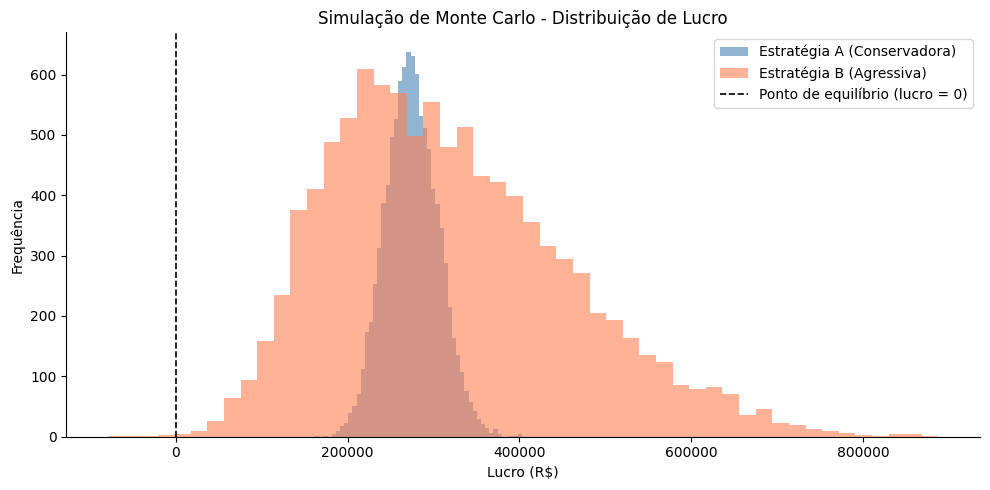

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(lucro_a, bins=50, alpha=0.6, color='steelblue', label='Estratégia A (Conservadora)')
plt.hist(lucro_b, bins=50, alpha=0.6, color='coral', label='Estratégia B (Agressiva)')

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2, label='Ponto de equilíbrio (lucro = 0)')

plt.title('Simulação de Monte Carlo - Distribuição de Lucro')
plt.xlabel('Lucro (R$)')
plt.ylabel('Frequência')
plt.legend()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**3: Cálculo de Probabilidades**
Calcule e exiba as seguintes métricas para cada estratégia:

Média de Lucro.

Probabilidade de Prejuízo (porcentagem de simulações onde o lucro foi < 0).

In [8]:
prob_prejuizo_a = np.mean(lucro_a < 0) * 100
prob_prejuizo_b = np.mean(lucro_b < 0) * 100

print("Estratégia A (Conservadora)")
print(f"Média de Lucro: R$ {media_lucro_a:,.2f}")
print(f"Probabilidade de Prejuízo: {prob_prejuizo_a:.1f}%")

print("\nEstratégia B (Agressiva)")
print(f"Média de Lucro: R$ {media_lucro_b:,.2f}")
print(f"Probabilidade de Prejuízo: {prob_prejuizo_b:.1f}%")

=== Estratégia A (Conservadora) ===
Média de Lucro: R$ 274,790.24
Probabilidade de Prejuízo: 0.0%

=== Estratégia B (Agressiva) ===
Média de Lucro: R$ 318,617.76
Probabilidade de Prejuízo: 0.1%
